<div style="
    font-size: 42px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
">
    Projet 6 - Classifiez automatiquement des biens de consommation
</div>

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Importation
</div>

In [1]:
# ================================
#  IMPORTS
# ================================
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import ast

# ================================
#  FONCTIONS
# ================================
def get_image_paths(image_dir, extensions=['.jpg', '.jpeg', '.png']):
    """
    Récupère les chemins des images dans un dossier.
    """
    p = Path(image_dir)
    paths = []
    for ext in extensions:
        paths += list(p.glob(f'*{ext}'))
    return sorted([str(p) for p in paths])

def load_and_resize_image(path, size=(224, 224), to_rgb=True):
    """
    Charge une image depuis un chemin et la redimensionne.
    """
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Impossible de lire {path}")
    if to_rgb:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, size)

def extract_main_category(tree_str):
    """
    Extrait la catégorie principale depuis le champ product_category_tree.
    """
    try:
        parts = ast.literal_eval(tree_str)
        main = parts[0]
        return main.split('>>')[0].strip()
    except Exception:
        return None

# ================================
#  IMPORTATION DES DONNÉES
# ================================
# Définir le chemin vers les images et le fichier CSV
IMAGE_DIR = r'C:\Users\chouh\OneDrive\Desktop\Openclassrooms\Formation Data Scientist\projet 6\Flipkart\Images'
CSV_PATH = r'C:\Users\chouh\OneDrive\Desktop\Openclassrooms\Formation Data Scientist\projet 6\Flipkart\flipkart_com-ecommerce_sample_1050.csv'

# 1. Récupération des chemins d’images
paths = get_image_paths(IMAGE_DIR)
print(f"{len(paths)} fichiers images trouvés dans « {IMAGE_DIR} »")

# 2. Construction du DataFrame des images
df_images = pd.DataFrame({'image_path': paths})
df_images['uniq_id'] = df_images['image_path'].apply(lambda p: Path(p).stem)

# 3. Chargement du fichier texte produit
df_texte = pd.read_csv(CSV_PATH)

# 4. Extraction de la catégorie principale
df_texte['main_category'] = df_texte['product_category_tree'] \
    .astype(str) \
    .apply(extract_main_category)

# 5. Fusion des images et des catégories
df_images = df_images.merge(
    df_texte[['uniq_id', 'main_category']],
    on='uniq_id',
    how='left'
)

# 6. Vérification des résultats
print(df_images.columns)
print(df_images['main_category'].value_counts())

1050 fichiers images trouvés dans « C:\Users\chouh\OneDrive\Desktop\Openclassrooms\Formation Data Scientist\projet 6\Flipkart\Images »
Index(['image_path', 'uniq_id', 'main_category'], dtype='object')
main_category
Watches                       150
Kitchen & Dining              150
Home Furnishing               150
Beauty and Personal Care      150
Computers                     150
Home Decor & Festive Needs    150
Baby Care                     150
Name: count, dtype: int64



=== Watches ===


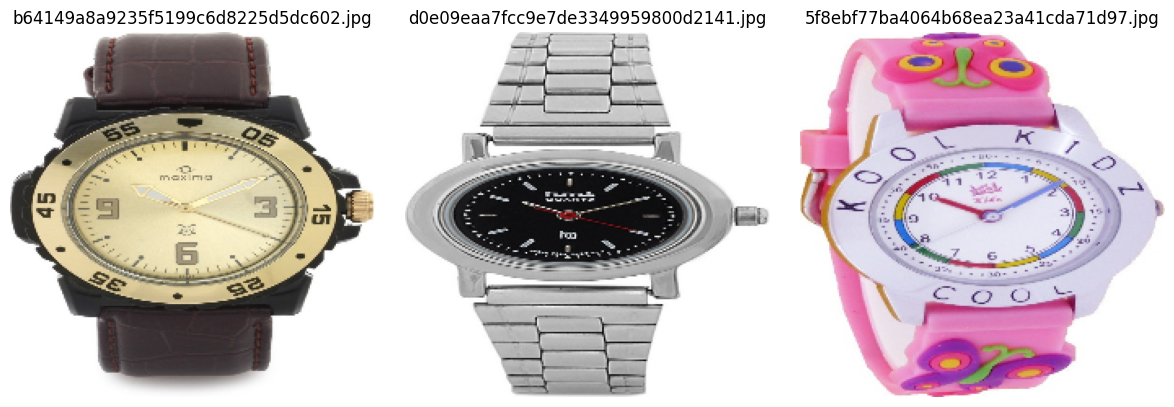


=== Kitchen & Dining ===


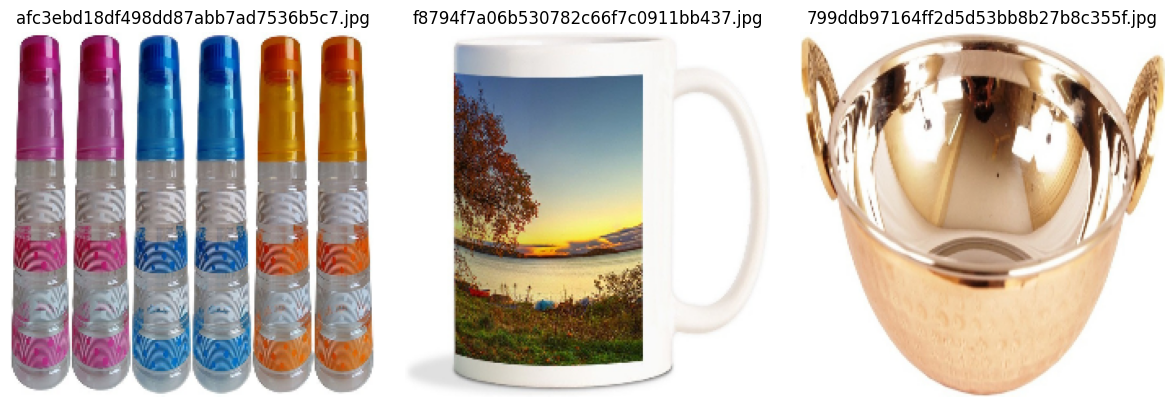


=== Home Furnishing ===


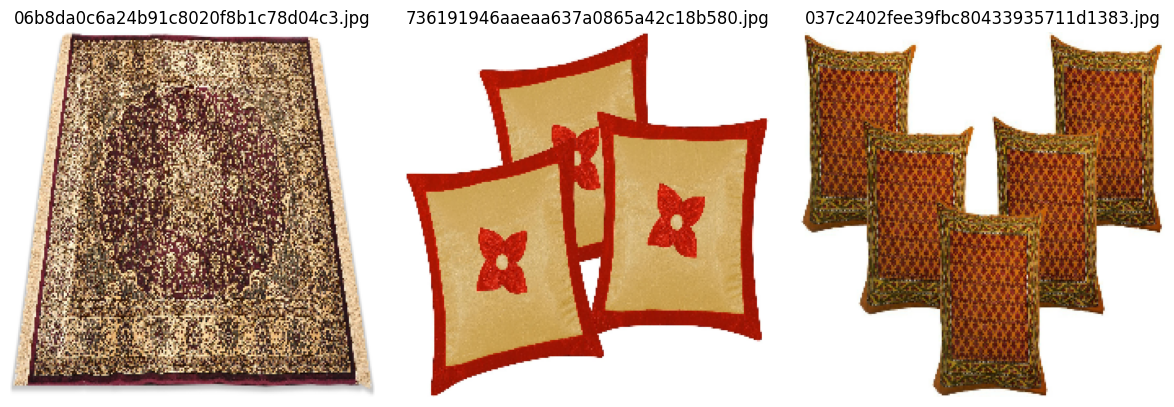


=== Beauty and Personal Care ===


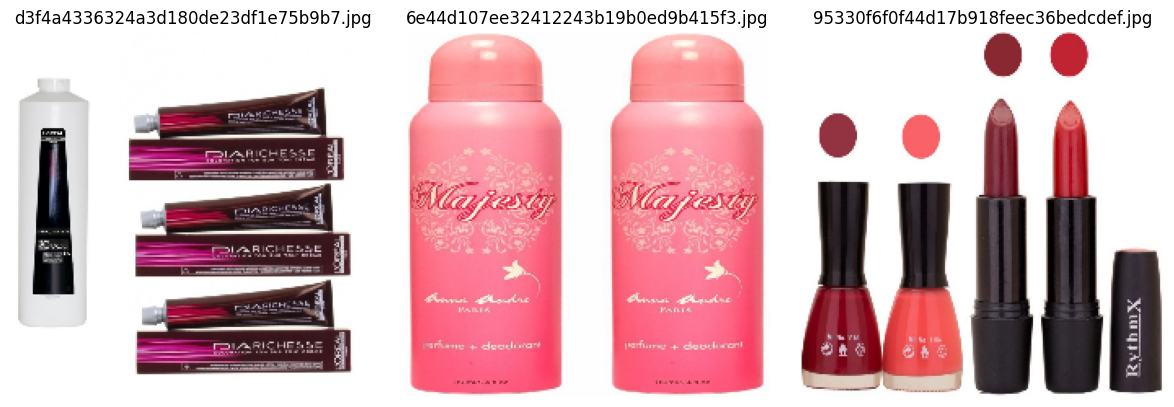


=== Computers ===


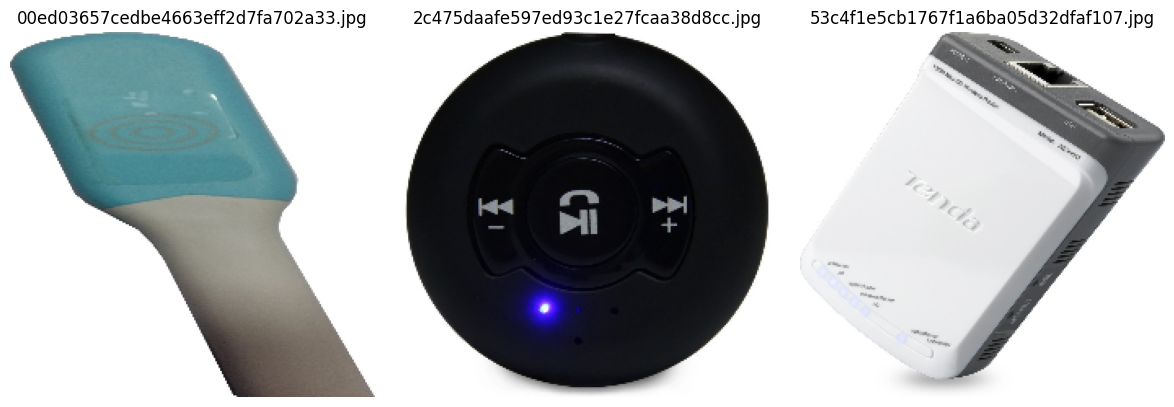


=== Home Decor & Festive Needs ===


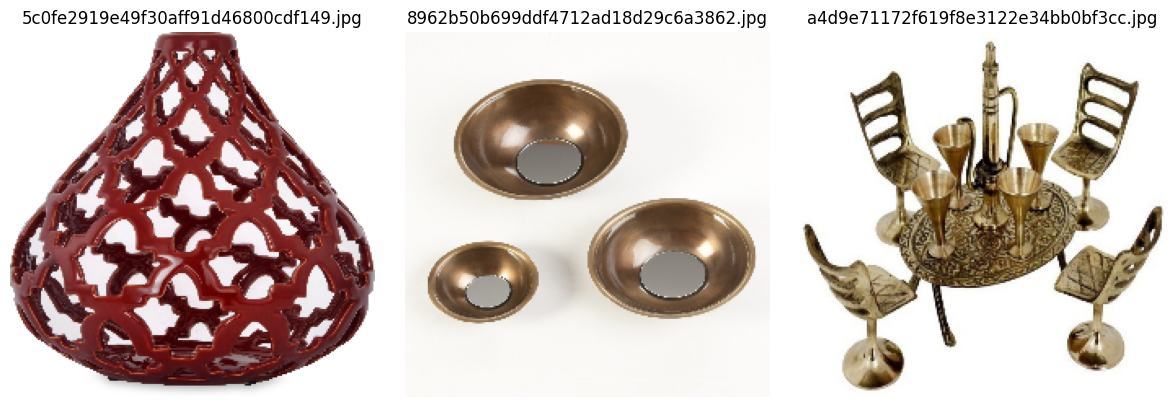


=== Baby Care ===


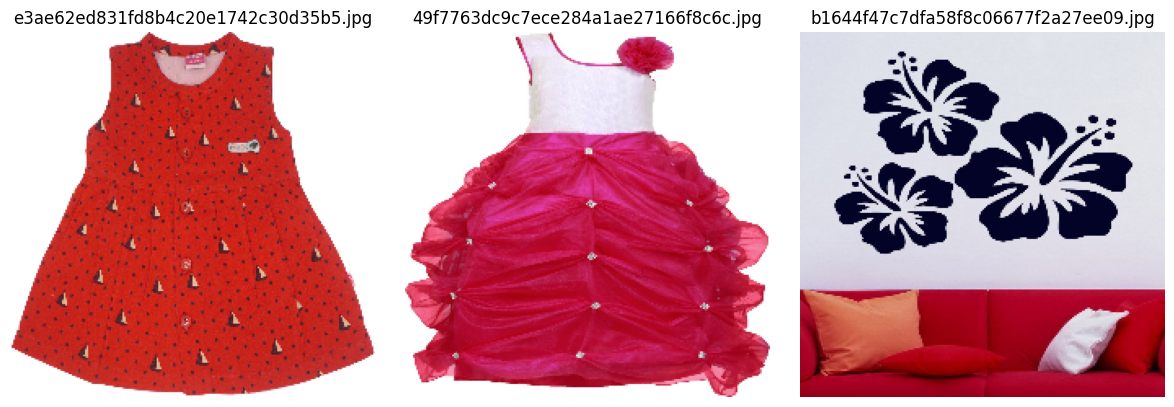

In [2]:
# ================================
#   AFFICHAGE D'EXEMPLES D'IMAGES PAR CATÉGORIE
# ================================
import random

N_EXAMPLES = 3  # Nombre d'exemples à afficher par catégorie
cats = df_images['main_category'].dropna().unique().tolist()

for cat in cats:
    print(f"\n=== {cat} ===")
    # Sélection des images de cette catégorie
    sub_df = df_images[df_images['main_category'] == cat]
    image_paths = sub_df['image_path'].tolist()
    
    # Échantillonnage d'images (au cas où il y aurait moins d'images que demandé)
    sampled_paths = random.sample(image_paths, min(N_EXAMPLES, len(image_paths)))
    
    # Affichage des images
    fig, axes = plt.subplots(1, len(sampled_paths), figsize=(4 * len(sampled_paths), 4))
    if len(sampled_paths) == 1:
        axes = [axes]  # rendre itérable même s'il n'y a qu'une seule image
    
    for i, img_path in enumerate(sampled_paths):
        img = load_and_resize_image(img_path, size=(224, 224))
        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(Path(img_path).name)
    
    plt.tight_layout()
    plt.show()

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Etape 3 - Etudier la faisabilité de classification en utilisant des techniques de traitement d'image basique
</div>

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    SIFT
</div>

Dans cette partie, nous avons utilisé la méthode SIFT, une technique qui permet de détecter les éléments visuels clés d’une image, comme les formes ou les textures. Cela nous permet de résumer chaque image sous forme numérique, sans dépendre de sa taille ou de son orientation.

Concrètement, nous avons d’abord préparé les images (redimensionnement et passage en niveaux de gris), puis utilisé SIFT pour en extraire plusieurs centaines de descripteurs visuels. Nous avons ensuite regroupé ces motifs en un vocabulaire commun grâce à un algorithme de regroupement (KMeans).

Chaque image a ainsi été représentée par un histogramme indiquant la fréquence des motifs identifiés, une méthode appelée Bag of Visual Words. Cette approche nous permet d’obtenir une description numérique fiable de chaque image, prête à être utilisée pour la suite de notre analyse.

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Conversion en niveau de gris
</div>

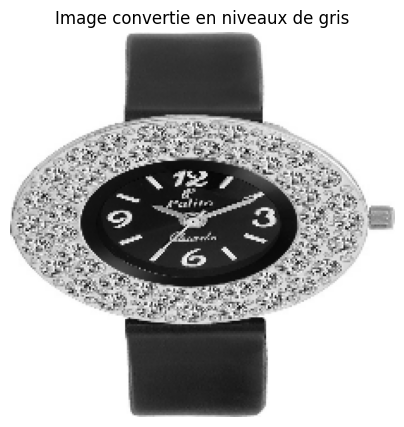

In [3]:
# ================================
#  1. CONVERSION EN NIVEAUX DE GRIS
# ================================
import numpy as np

def to_grayscale(image: np.ndarray) -> np.ndarray:
    """
    Convertit une image RGB (H×W×3) en niveaux de gris (H×W).
    """
    return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Sélection d'une image exemple
sample_path = df_images['image_path'].iloc[0]
sample_img = load_and_resize_image(sample_path, size=(224, 224))

# Application de la conversion en niveaux de gris
sample_gray = to_grayscale(sample_img)

# Affichage de l'image en niveaux de gris
plt.figure(figsize=(5, 5))
plt.imshow(sample_gray, cmap='gray')
plt.title("Image convertie en niveaux de gris")
plt.axis('off')
plt.show()

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Normalisation des pixels
</div>

Min pixel: 0.007843138
Max pixel: 1.0


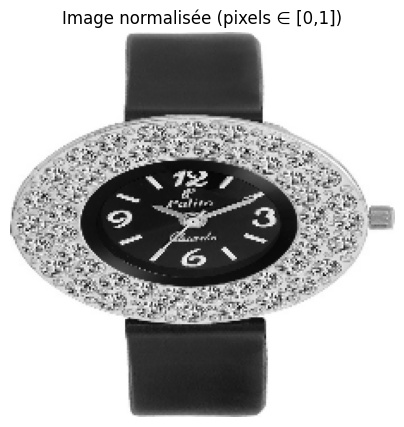

In [4]:
# ================================
#  2. NORMALISATION DES PIXELS
# ================================
def normalize_pixels(image: np.ndarray) -> np.ndarray:
    """
    Normalise une image uint8 en float32 dans l'intervalle [0, 1].
    """
    return image.astype(np.float32) / 255.0

# Application de la normalisation sur l'image en niveaux de gris
sample_norm = normalize_pixels(sample_gray)

# Vérification des valeurs normalisées
print("Min pixel:", sample_norm.min())
print("Max pixel:", sample_norm.max())

# Affichage de l'image normalisée
plt.figure(figsize=(5, 5))
plt.imshow(sample_norm, cmap='gray')
plt.title("Image normalisée (pixels ∈ [0,1])")
plt.axis('off')
plt.show()

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Extraction des descripteurs
</div>

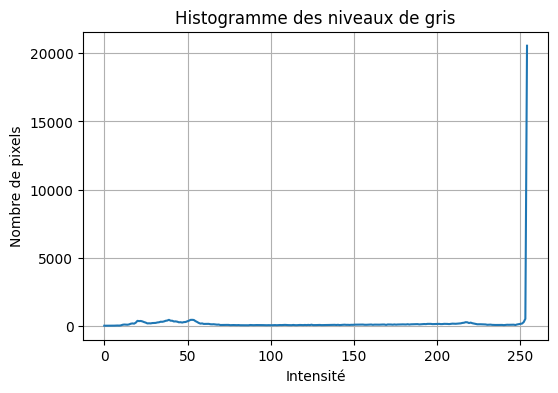

In [5]:
# ================================
#  3. AFFICHAGE DE L’HISTOGRAMME
# ================================
def plot_image_histogram(image_gray: np.ndarray, bins: int = 256) -> None:
    """
    Trace l’histogramme des intensités d’une image en niveaux de gris.
    """
    pixels = image_gray.flatten()
    vmin, vmax = (0, 255) if image_gray.dtype == np.uint8 else (0.0, 1.0)
    hist, edges = np.histogram(pixels, bins=bins, range=(vmin, vmax))

    plt.figure(figsize=(6, 4))
    plt.plot(edges[:-1], hist, lw=1.5)
    plt.title("Histogramme des niveaux de gris")
    plt.xlabel("Intensité")
    plt.ylabel("Nombre de pixels")
    plt.grid(True)
    plt.show()

# Affichage de l’histogramme pour l’image en niveaux de gris
plot_image_histogram(sample_gray)

In [6]:
# ================================
#  4. EXTRACTION DESCRIPTEURS SIFT SUR UNE IMAGE
# ================================
def extract_sift_descriptors(image_gray: np.ndarray, n_features: int = 500) -> np.ndarray:
    """
    Extrait les descripteurs SIFT d'une image en niveaux de gris.
    Retourne un tableau de descripteurs ou None si aucun point détecté.
    """
    sift = cv2.SIFT_create(nfeatures=n_features)
    keypoints, descriptors = sift.detectAndCompute(image_gray, None)
    return descriptors  # Peut être None

# Exemple avec une image
sample_path = df_images['image_path'].iloc[0]
sample_img = load_and_resize_image(sample_path, size=(224, 224))
sample_gray = to_grayscale(sample_img)

descriptors = extract_sift_descriptors(sample_gray, n_features=500)

if descriptors is not None:
    print(f"SIFT : {descriptors.shape[0]} descripteurs extraits (128-dimensionnels)")
else:
    print("Aucun point d’intérêt détecté par SIFT.")

SIFT : 321 descripteurs extraits (128-dimensionnels)


In [7]:
# ================================
#  5. EXTRACTION SIFT POUR TOUTES LES IMAGES (Liste complète alignée avec comptage des features)
# ================================
descriptor_list = []
failed = []
n_descriptors_total = 0
n_images_valide = 0

for idx, img_path in enumerate(paths):
    try:
        img_rgb = load_and_resize_image(img_path, size=(224, 224))
        img_gray = to_grayscale(img_rgb)
        desc = extract_sift_descriptors(img_gray, n_features=500)
    except Exception as e:
        desc = None
        failed.append((idx, img_path, str(e)))

    if desc is not None:
        n_images_valide += 1
        n_descriptors_total += desc.shape[0]
    
    descriptor_list.append(desc)  # Toujours ajouter pour garder l'alignement

# Résumé
print(f"{len(failed)} image(s) ont échoué sur {len(paths)}")
print(f"{n_images_valide} image(s) contiennent des descripteurs SIFT valides")
print(f"Nombre total de descripteurs extraits : {n_descriptors_total}")
assert len(descriptor_list) == len(paths)

0 image(s) ont échoué sur 1050
1049 image(s) contiennent des descripteurs SIFT valides
Nombre total de descripteurs extraits : 240824


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Réduction de dimension avec ACP
</div>

In [8]:
# ================================
#  6. RÉDUCTION DE DIMENSION AVEC PCA
# ================================
from sklearn.decomposition import PCA

# Empilement des descripteurs valides
valid_descriptors = [d for d in descriptor_list if d is not None]
all_descriptors = np.vstack(valid_descriptors)

pca = PCA(n_components=0.99, whiten=False, random_state=42)
pca.fit(all_descriptors)

print(f"Nombre de composantes retenues : {pca.n_components_}")

desc_pca_all = pca.transform(all_descriptors)

Nombre de composantes retenues : 109


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Kmeans
</div>

In [9]:
# ================================
#  7. CONSTRUCTION DU VOCABULAIRE VISUEL (KMEANS)
# ================================
from sklearn.cluster import MiniBatchKMeans

K = 50  # Nombre de clusters (mots visuels)
mbk = MiniBatchKMeans(n_clusters=K, batch_size=3072, random_state=42)  # Amélioration batch_size
mbk.fit(desc_pca_all)

C:\Users\chouh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\chouh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\chouh\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\chouh\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\chouh\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(e

MiniBatchKMeans(batch_size=3072, n_clusters=50, random_state=42)

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Bag of Visual Words
</div>

In [10]:
# ================================
#  8. CONSTRUCTION DES HISTOGRAMMES BoVW
# ================================
def compute_bovw_histograms(descriptor_list, pca, kmeans_model, K):
    """
    Calcule les histogrammes BoVW pour chaque image.
    """
    histograms = []
    for desc in descriptor_list:
        if desc is None or len(desc) == 0:
            histograms.append(np.zeros(K, dtype=int))
        else:
            desc_pca = pca.transform(desc)
            labels = kmeans_model.predict(desc_pca)
            hist, _ = np.histogram(labels, bins=np.arange(K + 1))
            histograms.append(hist)
    return np.vstack(histograms)

# Calcul des histogrammes BoVW
bow_features = compute_bovw_histograms(descriptor_list, pca, mbk, K)

print("BoVW features shape :", bow_features.shape)
assert bow_features.shape[0] == len(paths)  # Doit être 1050
print("Exemple d’histogrammes :", bow_features[:5])

BoVW features shape : (1050, 50)
Exemple d’histogrammes : [[  2   5   3   2   0   2   5   5  23   2  19   1   6   2  27   6   3   2
    3   2   5   4   5   2   0  28  16  10   5  33   1  10   2   1   4   4
    6   6   2   3   0   4   1  31   2   1   4   5   2   4]
 [  0   0   0   0   0   0   0   2   3   0   0   1   0   0   2   1   3   0
    1   1   0   1   0   0   2   3   6   1   0   0   2   0   0   0   0   1
    2   2   0   2   0   0   0   1   0   1   0   0   1   1]
 [  0   0   0   1 124   1   0   0   0   1   0   0   0   2   0   0   6   0
    0   0   1   0   0   0   0   0   4   0   1   0   0   0   0  49   1   0
    0   0   1   0  30   0  10   0   0   0   0   0   0   0]
 [  3   6   0   4   9   3   3   5  14  12   0   9   6   1   3   6   6   0
    7   5   1  10  18   2   0  10  26   0   7   1   2   2   5   4   9   1
   12   0   8   8   4   4   2   7   3   0   2   1   1   1]
 [  3   0   1   0   2   1   1   0  32   3   0   6   0   0   0   1   2   0
    0   0   0   3   0   0   2   0  23   

In [11]:
# ================================
#  9. CALCUL DES VRAIES ÉTIQUETTES
# ================================
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_true = le.fit_transform(df_images['main_category'])

print("Shape des labels :", y_true.shape)
print("Nombre de classes :", len(le.classes_))
assert y_true.shape[0] == len(paths)

Shape des labels : (1050,)
Nombre de classes : 7


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Evaluation du modèle SIFT avec T-SNE & ARI
</div>

In [12]:
# ================================
#  10. DÉFINITION DE LA FONCTION ARI + t-SNE
# ================================
import time
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def ARI_fct(features, y_true, n_clusters, random_state=42):
    """
    Applique t-SNE, KMeans et calcule l'ARI.
    """
    t0 = time.time()
    data = features.toarray() if hasattr(features, "toarray") else features

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        n_iter=1000,
        init='random',
        random_state=random_state
    )
    X2d = tsne.fit_transform(data)

    kmeans = KMeans(
        n_clusters=n_clusters,
        n_init=50,
        random_state=random_state
    )
    y_pred = kmeans.fit_predict(X2d)

    ari = adjusted_rand_score(y_true, y_pred)
    dt = time.time() - t0
    print(f"ARI = {ari:.3f}   (temps {dt:.2f}s)")

    return ari, X2d, y_pred

In [13]:
import matplotlib.patches as mpatches

def TSNE_visu_fct(X2d, y_true, y_pred, ari, label_names):
    """
    Affiche les résultats t-SNE avec vraies classes et clusters.
    """
    cmap = plt.get_cmap('tab10')
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Vue avec vraies classes
    axes[0].scatter(X2d[:, 0], X2d[:, 1], c=y_true, cmap=cmap, s=15)
    axes[0].set_title("t-SNE – Catégories réelles")
    handles_true = [mpatches.Patch(color=cmap(i), label=str(lab)) for i, lab in enumerate(label_names)]
    labels_true = [str(lab) for lab in label_names]
    axes[0].legend(handles_true, labels_true, title="Catégories")

    # Vue avec clusters
    axes[1].scatter(X2d[:, 0], X2d[:, 1], c=y_pred, cmap=cmap, s=15)
    axes[1].set_title("t-SNE – Clusters KMeans")
    handles_pred = [mpatches.Patch(color=cmap(i), label=f"Cluster {i}") for i in range(len(label_names))]
    labels_pred = [f"Cluster {i}" for i in range(len(label_names))]
    axes[1].legend(handles_pred, labels_pred, title="Clusters")

    plt.suptitle(f"t-SNE & ARI = {ari:.3f}", fontsize=14)
    plt.tight_layout()
    plt.show()

C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


ARI = 0.065   (temps 7.14s)


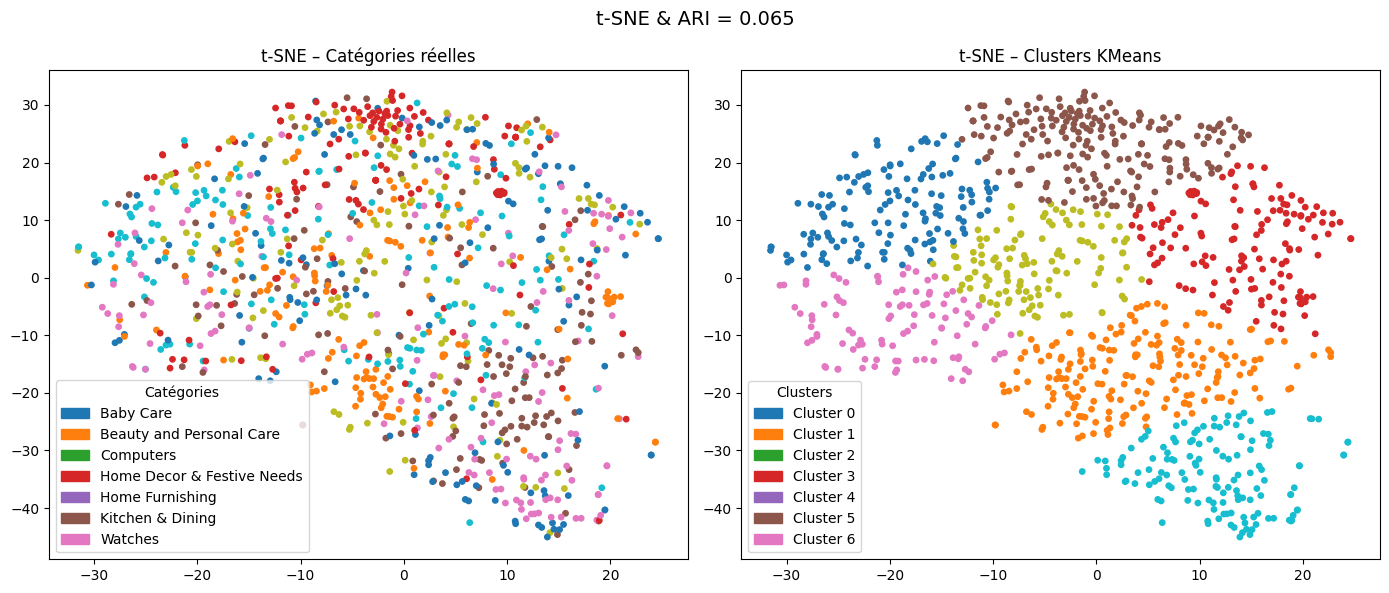

In [14]:
# ================================
#  12. APPLICATION ARI ET VISUALISATION t-SNE
# ================================
ari, X2d, y_pred = ARI_fct(bow_features, y_true, n_clusters=len(le.classes_))
TSNE_visu_fct(X2d, y_true, y_pred, ari, le.classes_)

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    Etape 4 - Etudier la faisabilité de classification automatique en utilisant des techniques de traitement d'image plus avancées
</div>

<div style="
    font-size: 32px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #1f2937;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 10px;
    margin: 30px 0 20px 0;
    text-align: center
">
    VGG16
</div>

Dans la seconde partie de notre étude, nous avons utilisé VGG16, un modèle de reconnaissance d’images déjà entraîné sur des millions d’exemples.
Ce type de modèle, appelé réseau de neurones convolutif (CNN), est aujourd’hui une référence dans l’analyse d’images.

VGG16 a l’avantage de savoir repérer automatiquement les formes, les objets et les détails visuels d’une image, sans que nous ayons besoin de les définir manuellement.
Nous avons utilisé ce modèle pour extraire une description numérique avancée de chaque image, appelée "feature vector".

Ces descriptions, bien plus riches que celles de la méthode SIFT, nous permettent de mieux distinguer les images entre elles et de les classer plus efficacement.
Cette étape nous offre une base solide pour réaliser des regroupements ou des classifications automatiques dans la suite du projet.

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Création du modèle
</div>

In [57]:
# ─── IMPORTS ───────────────────────────────────────────────────────────────
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ─── CRÉATION DU MODÈLE VGG16 ───────────────────────────────────────────────
# Chargement du modèle pré-entraîné VGG16 sans la dernière couche de classification
base_model = VGG16()
model = Model(inputs=base_model.inputs, outputs=base_model.layers[-2].output)

# Affichage du résumé du modèle
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Extraction des features
</div>

In [59]:
# ─── EXTRACTION DES FEATURES DES IMAGES ─────────────────────────────────────
images_features = []
i = 0

for image_file in df_images["image_path"]:
    if i % 100 == 0:
        print(f"Traitement de l'image {i}/{len(df_images)}")
    i += 1

    # Chargement et préparation de l'image
    image = load_img(image_file, target_size=(224, 224))
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    # Extraction des features avec le modèle VGG16
    features = model.predict(image, verbose=0)[0]
    images_features.append(features)

# Conversion en tableau numpy
images_features = np.asarray(images_features)
print("Shape des features extraites :", images_features.shape)

Traitement de l'image 0/1050


C:\Users\chouh\anaconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Traitement de l'image 100/1050
Traitement de l'image 200/1050
Traitement de l'image 300/1050


C:\Users\chouh\anaconda3\Lib\site-packages\PIL\Image.py:3368: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Traitement de l'image 400/1050
Traitement de l'image 500/1050
Traitement de l'image 600/1050
Traitement de l'image 700/1050
Traitement de l'image 800/1050
Traitement de l'image 900/1050
Traitement de l'image 1000/1050
Shape des features extraites : (1050, 4096)


In [61]:
# ─── RÉDUCTION DE DIMENSION AVEC PCA ────────────────────────────────────────
from sklearn.decomposition import PCA

print("Shape avant PCA :", images_features.shape)

# Instanciation de la PCA pour expliquer 99% de la variance
pca = PCA(n_components=0.99)
feat_pca = pca.fit_transform(images_features)

print("Shape après PCA :", feat_pca.shape)

Shape avant PCA : (1050, 4096)
Shape après PCA : (1050, 803)


In [63]:
# ─── RÉDUCTION AVEC T-SNE ───────────────────────────────────────────────────
from sklearn.manifold import TSNE
import time

start_time = time.time()

tsne = TSNE(n_components=2, perplexity=30, n_iter=2000, init='random', random_state=6)
X_tsne = tsne.fit_transform(feat_pca)

duration = time.time() - start_time
print(f"Durée du t-SNE : {duration:.2f} secondes")

C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Durée du t-SNE : 11.18 secondes


<div style="
    font-size: 24px;
    font-weight: bold;
    font-family: Segoe UI;
    color: #374151;
    border-left: 5px solid #3b82f6;
    padding-left: 12px;
    margin: 25px 0 15px 0;
">
    Evaluation du modèle
</div>

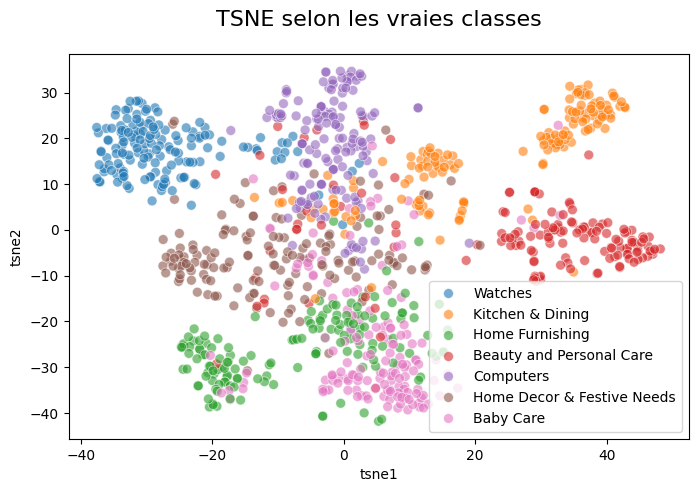

In [65]:
# ─── VISUALISATION AVEC SEABORN ─────────────────────────────────────────────
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Création d'un DataFrame pour le t-SNE
df_tsne = pd.DataFrame(X_tsne, columns=['tsne1', 'tsne2'])
df_tsne["class"] = df_images["main_category"]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="tsne1", y="tsne2",
    hue="class",
    palette=sns.color_palette('tab10', n_colors=len(df_images["main_category"].unique())),
    s=50, alpha=0.6,
    data=df_tsne,
    legend="brief"
)

plt.title('TSNE selon les vraies classes', fontsize=16, pad=20)
plt.xlabel('tsne1')
plt.ylabel('tsne2')
plt.legend(prop={'size': 10})
plt.show()

C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


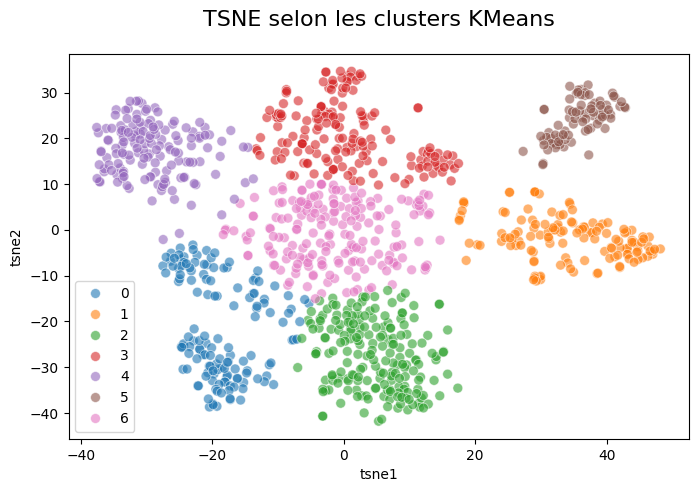

ARI : 0.4501087681893793


In [67]:
# ─── CLUSTERING AVEC KMEANS ─────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn import metrics

# Clustering KMeans sur les données projetées en 2D
n_clusters = df_images["main_category"].nunique()  # nombre de vraies catégories
cls = KMeans(n_clusters=n_clusters, n_init=100, random_state=42)
cls.fit(X_tsne)

# Attribution des clusters au DataFrame t-SNE
df_tsne["cluster"] = cls.labels_

# Visualisation des clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="tsne1", y="tsne2",
    hue="cluster",
    palette=sns.color_palette('tab10', n_colors=n_clusters),
    s=50, alpha=0.6,
    data=df_tsne,
    legend="brief"
)

plt.title('TSNE selon les clusters KMeans', fontsize=16, pad=20)
plt.xlabel('tsne1')
plt.ylabel('tsne2')
plt.legend(prop={'size': 10})
plt.show()

# ─── CALCUL DE L’ARI ────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_true = le.fit_transform(df_images["main_category"])

ari_score = metrics.adjusted_rand_score(y_true, cls.labels_)
print("ARI :", ari_score)

In [69]:
# ─── FONCTION DE TRANSFORMATION DES CLUSTERS EN CLASSES ─────────────────────
import numpy as np
import pandas as pd

def conf_mat_transform(y_true, y_pred):
    """
    Aligne les clusters KMeans avec les vraies classes en utilisant la matrice de confusion.
    """
    conf_mat = metrics.confusion_matrix(y_true, y_pred)
    corresp = np.argmax(conf_mat, axis=0)
    print("Correspondance des clusters :", corresp)
    
    # Application de la correspondance
    labels_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    labels_df["y_pred_transform"] = labels_df["y_pred"].apply(lambda x: corresp[x])
    
    return labels_df["y_pred_transform"]

Correspondance des clusters : [4 1 0 2 6 5 3]
[[110   3   1  26   8   1   1]
 [  4 117   8  13   6   1   1]
 [  1   1 108  39   0   0   1]
 [  2   1   5  76  58   0   8]
 [ 77   0   0   4  69   0   0]
 [  0  10  32  30   0  78   0]
 [  0   0  13   2   0   0 135]]
              precision    recall  f1-score   support

           0       0.57      0.73      0.64       150
           1       0.89      0.78      0.83       150
           2       0.65      0.72      0.68       150
           3       0.40      0.51      0.45       150
           4       0.49      0.46      0.47       150
           5       0.97      0.52      0.68       150
           6       0.92      0.90      0.91       150

    accuracy                           0.66      1050
   macro avg       0.70      0.66      0.67      1050
weighted avg       0.70      0.66      0.67      1050



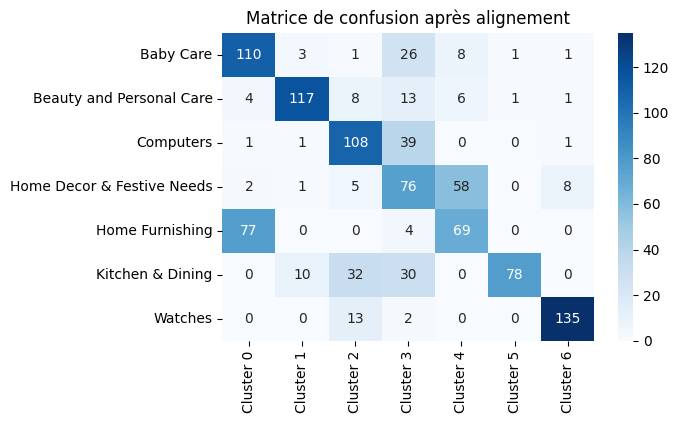

In [71]:
# ─── APPLICATION ET AFFICHAGE DE LA MATRICE DE CONFUSION ─────────────────────
cls_labels_transform = conf_mat_transform(y_true, cls.labels_)

# Nouvelle matrice de confusion
conf_mat = metrics.confusion_matrix(y_true, cls_labels_transform)
print(conf_mat)

# Rapport détaillé
print(metrics.classification_report(y_true, cls_labels_transform))

# Affichage avec seaborn
import seaborn as sns
import matplotlib.pyplot as plt

df_cm = pd.DataFrame(conf_mat, index=le.classes_, columns=[f"Cluster {i}" for i in range(n_clusters)])
plt.figure(figsize=(6, 4))
sns.heatmap(df_cm, annot=True, cmap="Blues", fmt='d')
plt.title("Matrice de confusion après alignement")
plt.show()